In [42]:
train_df = df_train

0    4342
1    3271
Name: target, dtype: int64

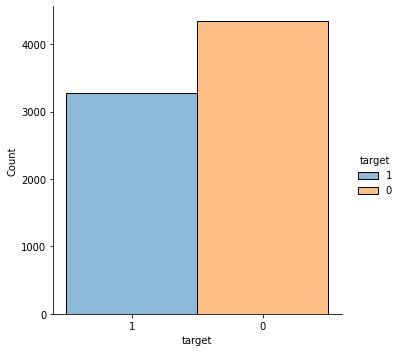

In [48]:
import seaborn as sns
# histogram of class labels
train_df['target'] = train_df['target'].astype(str)
sns.displot(data=train_df, x='target', hue='target')
train_df['target'].value_counts()

In [ ]:
## LSTM / GRU

In [8]:
#for data analysis and modeling
import tensorflow as tf
from tensorflow.keras.layers import LSTM, GRU, Dense, Embedding, Dropout
from tensorflow.keras.preprocessing import text, sequence 
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
#for text cleaning
import string
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
#for visualization
import matplotlib.pyplot as plt

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [11]:
%%time
def clean_text(txt):
    """""
    cleans the input text in the following steps
    1- replace contractions
    2- removing punctuation
    3- spliting into words
    4- removing stopwords
    5- removing leftover punctuations
    """""
    contraction_dict = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not", "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not", "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",  "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would", "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would", "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam", "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have", "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock", "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have", "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is", "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as", "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would", "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have", "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have", "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are", "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",  "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is", "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have", "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have", "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all", "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have","you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have", "you're": "you are", "you've": "you have"}
    def _get_contractions(contraction_dict):
        contraction_re = re.compile('(%s)' % '|'.join(contraction_dict.keys()))
        return contraction_dict, contraction_re

    def replace_contractions(text):
        contractions, contractions_re = _get_contractions(contraction_dict)
        def replace(match):
            return contractions[match.group(0)]
        return contractions_re.sub(replace, text)

    # replace contractions
    txt = replace_contractions(txt)
    
    #remove punctuations
    txt  = "".join([char for char in txt if char not in string.punctuation])
    txt = re.sub('[0-9]+', '', txt)
    
    # split into words
    words = word_tokenize(txt)
    
    # remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [w for w in words if not w in stop_words]
    
    # removing leftover punctuations
    words = [word for word in words if word.isalpha()]
    
    cleaned_text = ' '.join(words)
    return cleaned_text
    
df_train['text'] = df_train['text'].apply(lambda txt: clean_text(txt))
df_train.head()

CPU times: user 2.45 s, sys: 143 ms, total: 2.6 s
Wall time: 2.66 s


,keyword,location,text,target
id,,,,
1,NaN,NaN,Our Deeds Reason earthquake May ALLAH Forgive us,1
4,NaN,NaN,Forest fire near La Ronge Sask Canada,1
5,NaN,NaN,All residents asked shelter place notified off...,1
6,NaN,NaN,people receive wildfires evacuation orders Cal...,1
7,NaN,NaN,Just got sent photo Ruby Alaska smoke wildfire...,1


In [12]:
xtrain, xtest, ytrain, ytest = train_test_split(df_train['text'].values, df_train['target'].values, shuffle=True, test_size=0.2)

In [13]:
max_len = max(df_train['text'].apply(lambda x: len(x.split())).values)
max_len

28

In [14]:
max_words = 50
tokenizer = text.Tokenizer(num_words = max_words)
# create the vocabulary by fitting on x_train text
tokenizer.fit_on_texts(xtrain)
# generate the sequence of tokens
xtrain_seq = tokenizer.texts_to_sequences(xtrain)
xtest_seq = tokenizer.texts_to_sequences(xtest)

# pad the sequences
xtrain_pad = sequence.pad_sequences(xtrain_seq, maxlen=max_len)
xtest_pad = sequence.pad_sequences(xtest_seq, maxlen=max_len)
word_index = tokenizer.word_index

print('text example:', xtrain[0])
print('sequence of indices(before padding):', xtrain_seq[0])
print('sequence of indices(after padding):', xtrain_pad[0])

text example: stury Note passengers board train derailed morning
sequence of indices(before padding): []
sequence of indices(after padding): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
#https://nlp.stanford.edu/projects/glove/
!wget https://nlp.stanford.edu/data/glove.6B.zip
#!unzip g*zip

In [17]:
%%time
embedding_vectors = {}
with open('glove.6B.300d.txt','r',encoding='utf-8') as file: #glove.42B.300d.txt
    for row in file:
        values = row.split(' ')
        word = values[0]
        weights = np.asarray([float(val) for val in values[1:]])
        embedding_vectors[word] = weights
print(f"Size of vocabulary in GloVe: {len(embedding_vectors)}")  

Size of vocabulary in GloVe: 400000
CPU times: user 32.6 s, sys: 1.43 s, total: 34 s
Wall time: 32.9 s


In [18]:
#initialize the embedding_matrix with zeros
emb_dim = 300
if max_words is not None: 
    vocab_len = max_words 
else:
    vocab_len = len(word_index)+1
embedding_matrix = np.zeros((vocab_len, emb_dim))
oov_count = 0
oov_words = []
for word, idx in word_index.items():
    if idx < vocab_len:
        embedding_vector = embedding_vectors.get(word)
        if embedding_vector is not None:
            embedding_matrix[idx] = embedding_vector
        else:
            oov_count += 1 
            oov_words.append(word)
#print some of the out of vocabulary words
print(f'Some out of valubulary words: {oov_words[0:5]}')
print(f'{oov_count} out of {vocab_len} words were OOV.')

Some out of valubulary words: []
0 out of 50 words were OOV.


In [19]:
lstm_model = Sequential()
lstm_model.add(Embedding(vocab_len, emb_dim, trainable = False, weights=[embedding_matrix]))
lstm_model.add(LSTM(128, return_sequences=False))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(1, activation = 'sigmoid'))
lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print(lstm_model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 300)         15000     
                                                                 
 lstm (LSTM)                 (None, 128)               219648    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params: 234,777
Trainable params: 219,777
Non-trainable params: 15,000
_________________________________________________________________
None


In [20]:
%%time
batch_size = 256
epochs  = 10
history = lstm_model.fit(xtrain_pad, np.asarray(ytrain), validation_data=(xtest_pad, np.asarray(ytest)), batch_size = batch_size, epochs = epochs)

Epoch 1/10
24/24 [==============================] - 9s 32ms/step - loss: 0.6284 - accuracy: 0.6573 - val_loss: 0.6259 - val_accuracy: 0.6553
Epoch 2/10
24/24 [==============================] - 0s 10ms/step - loss: 0.5981 - accuracy: 0.6765 - val_loss: 0.6186 - val_accuracy: 0.6625
Epoch 3/10
24/24 [==============================] - 0s 9ms/step - loss: 0.5959 - accuracy: 0.6755 - val_loss: 0.6173 - val_accuracy: 0.6678
Epoch 4/10
24/24 [==============================] - 0s 9ms/step - loss: 0.5913 - accuracy: 0.6768 - val_loss: 0.6183 - val_accuracy: 0.6632
Epoch 5/10
24/24 [==============================] - 0s 8ms/step - loss: 0.5909 - accuracy: 0.6759 - val_loss: 0.6156 - val_accuracy: 0.6632
Epoch 6/10
24/24 [==============================] - 0s 8ms/step - loss: 0.5881 - accuracy: 0.6768 - val_loss: 0.6155 - val_accuracy: 0.6664
Epoch 7/10
24/24 [==============================] - 0s 8ms/step - loss: 0.5861 - accuracy: 0.6834 - val_loss: 0.6156 - val_accuracy: 0.6619
Epoch 8/10
24/24 [

In [21]:
lstm_model = Sequential()
lstm_model.add(Embedding(vocab_len, emb_dim)) #, trainable = True, weights=[embedding_matrix]))
#lstm_model.add(LSTM(32, return_sequences=True))
lstm_model.add(LSTM(64, activation='tanh', return_sequences=False))
lstm_model.add(Dense(128, activation='relu'))
#lstm_model.add(tf.keras.layers.BatchNormalization())
lstm_model.add(Dropout(0.2)) # Adding Dropout layer with rate of 0.2
lstm_model.add(Dense(256, activation='relu'))
lstm_model.add(Dense(128, activation='relu'))
lstm_model.add(Dense(64, activation='relu'))
lstm_model.add(Dense(1, activation='sigmoid'))
lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.AUC()])
print(lstm_model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, None, 300)         15000     
                                                                 
 lstm_1 (LSTM)               (None, 64)                93440     
                                                                 
 dense_1 (Dense)             (None, 128)               8320      
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 256)               33024     
                                                                 
 dense_3 (Dense)             (None, 128)               32896     
                                                                 
 dense_4 (Dense)             (None, 64)               

In [23]:
%%time
batch_size = 32
epochs  = 20
history = lstm_model.fit(xtrain_pad, np.asarray(ytrain), validation_data=(xtest_pad, np.asarray(ytest)), batch_size = batch_size, epochs = epochs)

Epoch 1/20
191/191 [==============================] - 2s 8ms/step - loss: 0.5358 - recall: 0.4506 - auc: 0.7707 - val_loss: 0.6897 - val_recall: 0.3477 - val_auc: 0.6696
Epoch 2/20
191/191 [==============================] - 2s 8ms/step - loss: 0.5337 - recall: 0.4525 - auc: 0.7735 - val_loss: 0.6992 - val_recall: 0.3462 - val_auc: 0.6701
Epoch 3/20
191/191 [==============================] - 2s 9ms/step - loss: 0.5328 - recall: 0.4510 - auc: 0.7737 - val_loss: 0.7409 - val_recall: 0.3338 - val_auc: 0.6629
Epoch 4/20
191/191 [==============================] - 2s 12ms/step - loss: 0.5290 - recall: 0.4479 - auc: 0.7769 - val_loss: 0.7440 - val_recall: 0.3369 - val_auc: 0.6605
Epoch 5/20
191/191 [==============================] - 2s 10ms/step - loss: 0.5233 - recall: 0.4556 - auc: 0.7804 - val_loss: 0.6939 - val_recall: 0.3723 - val_auc: 0.6656
Epoch 6/20
191/191 [==============================] - 2s 9ms/step - loss: 0.5225 - recall: 0.4468 - auc: 0.7775 - val_loss: 0.7837 - val_recall: 0.3

In [56]:
emb_dim = embedding_matrix.shape[1]
gru_model = Sequential()
gru_model.add(Embedding(vocab_len, emb_dim, trainable = False, weights=[embedding_matrix]))
gru_model.add(GRU(128, return_sequences=False))
gru_model.add(Dropout(0.5))
gru_model.add(Dense(1, activation = 'sigmoid'))
gru_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print(gru_model.summary())

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_11 (Embedding)    (None, None, 300)         15000     
                                                                 
 gru (GRU)                   (None, 128)               165120    
                                                                 
 dropout_10 (Dropout)        (None, 128)               0         
                                                                 
 dense_13 (Dense)            (None, 1)                 129       
                                                                 
Total params: 180,249
Trainable params: 165,249
Non-trainable params: 15,000
_________________________________________________________________
None


In [57]:
batch_size = 256
epochs  = 10
history = gru_model.fit(xtrain_pad, np.asarray(ytrain), validation_data=(xtest_pad, np.asarray(ytest)), batch_size = batch_size, epochs = epochs)

Epoch 1/10
24/24 [==============================] - 4s 27ms/step - loss: 0.6316 - accuracy: 0.6466 - val_loss: 0.6128 - val_accuracy: 0.6586
Epoch 2/10
24/24 [==============================] - 0s 11ms/step - loss: 0.6050 - accuracy: 0.6708 - val_loss: 0.6150 - val_accuracy: 0.6592
Epoch 3/10
24/24 [==============================] - 0s 10ms/step - loss: 0.5999 - accuracy: 0.6744 - val_loss: 0.6110 - val_accuracy: 0.6586
Epoch 4/10
24/24 [==============================] - 0s 8ms/step - loss: 0.5977 - accuracy: 0.6750 - val_loss: 0.6109 - val_accuracy: 0.6559
Epoch 5/10
24/24 [==============================] - 0s 8ms/step - loss: 0.5968 - accuracy: 0.6745 - val_loss: 0.6103 - val_accuracy: 0.6691
Epoch 6/10
24/24 [==============================] - 0s 8ms/step - loss: 0.5925 - accuracy: 0.6785 - val_loss: 0.6086 - val_accuracy: 0.6592
Epoch 7/10
24/24 [==============================] - 0s 7ms/step - loss: 0.5918 - accuracy: 0.6826 - val_loss: 0.6125 - val_accuracy: 0.6592
Epoch 8/10
24/24 

In [25]:
def clean1(tweet, http=True, punc=True, lem=True, stop_w=True):
    
    #substituion all the parts of the text, that has this formats 
    if http == True:
        tweet = re.sub('https?:\/\/t.co\/[A-Za-z0-9]*', '', tweet)
    
    #choose only one from NLTK or SpaCy with the best results
    if stop_w == 'nltk': #if stop_w=True
        tweet = [word for word in word_tokenize(tweet) if not word.lower() in nltk_st]
        tweet = ' '.join(tweet)
    
    #SpaCy has more stopwords around 400- so it can delete larger parts for my text, so that is the reason, that we will firstly use NLTK
    #if stop_w="spacy"
    elif stop_w == 'spacy':
        tweet = [word for word in word_tokenize(tweet) if not word.lower() in spacy_st]
        tweet = ' '.join(tweet)
      
    
    #lemmitizing
    if lem == True:
        lemmatized = [word.lemma_ for word in sp(tweet)] #lematizace z knihovny SpaCy
        tweet = ' '.join(lemmatized)
    
    #punctionation removal using translate- substitueting with blank space
    #Punctuation marks are symbols such as period (.), comma (,), semicolon (;), colon (:), question mark (?), exclamation mark (!), parentheses (), brackets [], braces {}, quotation marks "", apostrophe ('), and many others.
    if punc == True:
        tweet = tweet.translate(str.maketrans('', '', string.punctuation))
    
    #removing the extra space that may be around words or letters
    tweet = re.sub('\s+', ' ', tweet)
    
    return tweet

In [26]:
import string

df_train['text'] = df_train['text'].apply(lambda txt: clean1(txt))
df_test['text'] = df_test['text'].apply(lambda txt: clean1(txt))

In [28]:
from tensorflow.keras.layers import TextVectorization #podobné jako CountVectorizer, vhodné pro BidirectionalLSTM

In [29]:
X_train, y_train, X_test = df_train['text'].values, df_train['target'].values, df_test['text'].values

In [30]:
# Define for Embeddings layer as pre-processing layer for tokenization
MAX_FEATURES = 20000 #  20 000most frequent words in the input text data.

vectorizer = TextVectorization(max_tokens=MAX_FEATURES, 
                               output_sequence_length=200, 
                               output_mode='int') 
vectorizer.adapt(X_train) #vypisuje všechna slova, co se vyskytují v dokuemntu
vectorizer.get_vocabulary()[:20]


['',
 '[UNK]',
 'i',
 'the',
 'like',
 'get',
 'fire',
 'a',
 'go',
 'be',
 'amp',
 'new',
 'via',
 'one',
 'in',
 'say',
 'people',
 'news',
 'see',
 'to']

In [31]:
vectorizerd_text = vectorizer(X_train)

dataset = tf.data.Dataset.from_tensor_slices((vectorizerd_text, y_train))
dataset = dataset.cache() #metody pro dataset v TensoFlow
dataset = dataset.shuffle(160000)
dataset = dataset.batch(32) 
dataset = dataset.prefetch(8)

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Bidirectional, LSTM
from tensorflow.keras.metrics import Recall

model = Sequential()

model.add(Embedding(MAX_FEATURES + 1, 64))
model.add(Bidirectional(LSTM(64, activation='tanh')))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2)) # Adding Dropout layer with rate of 0.2
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='BinaryCrossentropy', optimizer='Adam', metrics=[Recall()])

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, None, 64)          1280064   
                                                                 
 bidirectional (Bidirectiona  (None, 128)              66048     
 l)                                                              
                                                                 
 dense_6 (Dense)             (None, 128)               16512     
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_7 (Dense)             (None, 256)               33024     
                                                                 
 dense_8 (Dense)             (None, 128)               32896     
                                                      

In [38]:
train_size = 20
valid_size = 30
test_size = 50

train = dataset.take(train_size)
valid = dataset.skip(train_size)

In [40]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

hist= model.fit(train, epochs=30, batch_size=32, validation_data=valid)

Epoch 1/30
20/20 [==============================] - 9s 448ms/step - loss: 0.6914 - recall_1: 0.0000e+00 - val_loss: 0.6813 - val_recall_1: 0.0000e+00
Epoch 2/30
20/20 [==============================] - 9s 446ms/step - loss: 0.6785 - recall_1: 0.0000e+00 - val_loss: 0.6528 - val_recall_1: 0.0000e+00
Epoch 3/30
20/20 [==============================] - 9s 440ms/step - loss: 0.6209 - recall_1: 0.3333 - val_loss: 0.5892 - val_recall_1: 0.3445
Epoch 4/30
20/20 [==============================] - 9s 467ms/step - loss: 0.4963 - recall_1: 0.6429 - val_loss: 0.4755 - val_recall_1: 0.7881
Epoch 5/30
20/20 [==============================] - 9s 465ms/step - loss: 0.4609 - recall_1: 0.6520 - val_loss: 0.4090 - val_recall_1: 0.6615
Epoch 6/30
20/20 [==============================] - 9s 465ms/step - loss: 0.4182 - recall_1: 0.7083 - val_loss: 0.3781 - val_recall_1: 0.7023
Epoch 7/30
20/20 [==============================] - 9s 443ms/step - loss: 0.4192 - recall_1: 0.7000 - val_loss: 0.3719 - val_recall_

<Figure size 576x360 with 0 Axes>

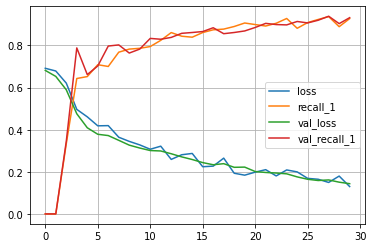

In [50]:
plt.figure(figsize=(8, 5))
pd.DataFrame(hist.history).plot()
plt.grid()
plt.show()

In [41]:
vectorizerd_test_text = vectorizer(X_test)
preds = []

for input_text in vectorizerd_test_text:    
    pred = model.predict(np.expand_dims(input_text, 0))    
    preds.append(pred)

preds = np.round(np.array(preds))
sub_sample = pd.read_csv('sample_submission.csv')
sub_sample['target'] = preds.flatten()
sub_sample['target'] = sub_sample['target'].astype('int')
sub_sample.to_csv('submission.csv', index=False)

1/1 [==============================] - 0s 34ms/step


/usr/local/lib/python3.9/dist-packages/tensorflow/python/data/ops/structured_function.py:256: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


1/1 [==============================] - 0s 39ms/step
